In [2]:
# ⬇️ Install (bitsandbytes pulls CUDA wheels automatically on Colab GPUs)
!pip -q install transformers accelerate bitsandbytes huggingface_hub --upgrade

# 🔑 Hugging Face login  – safest via env-var or an input prompt
import os, getpass
from huggingface_hub import login

HF_TOKEN = os.getenv("HF_TOKEN")          # recommended:  !export HF_TOKEN=your_token
if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)
print("✅ Authenticated")



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Authenticated


In [4]:
import os, json, pickle, re
from collections import defaultdict

import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import login

In [ ]:
# OPTION A – interactive upload (quick but resets every Colab restart)
from google.colab import files, drive

# files.upload() lets you choose multiple JSONs at once
uploaded = files.upload()   # pick your 4-5 JSON files
# they’ll land in /content/

# OPTION B – Google Drive (persistent)
# drive.mount("/content/drive")
# Then move / copy your JSONs inside /content/drive/MyDrive/...


Saving cnn_train_articles.json to cnn_train_articles.json
Saving cnn_train_gpt35_responses.json to cnn_train_gpt35_responses.json
Saving cnn_train_llama3.1-8b-instruct_responses.json to cnn_train_llama3.1-8b-instruct_responses.json
Saving cnn_train_llama3_8bchat_responses.json to cnn_train_llama3_8bchat_responses.json
Saving vector_steering_neg_clean.json to vector_steering_neg_clean.json
Saving vector_steering_pos_clean.json to vector_steering_pos_clean.json
Saving vector_steering_samples.json to vector_steering_samples.json
Saving vector_steering_samples_full_balanced.json to vector_steering_samples_full_balanced.json


In [41]:
uploaded = files.upload()

Saving steering_vectors_newbalancedtask3_meandiff.pkl to steering_vectors_newbalancedtask3_meandiff.pkl


In [88]:
import pathlib, shutil, os, json
# base = pathlib.Path("/content/data")
# (base / "articles").mkdir(parents=True, exist_ok=True)
# (base / "summaries").mkdir(parents=True, exist_ok=True)

# move uploaded files to the new folders; adjust names as needed
# uploaded_names = list(uploaded.keys())   # filenames you just uploaded
# mapping = {
#     "cnn_train_articles.json":           base / "articles/cnn_train_articles.json",
#     "cnn_train_llama3.1-8b-instruct_responses.json": base / "summaries/cnn_train_llama3.1-8b-instruct_responses.json",
#     "cnn_train_gpt35_responses.json":    base / "summaries/cnn_train_gpt35_responses.json",
#     "vector_steering_pos_clean.json":    base / "vector_steering_pos_clean.json",
#     "vector_steering_neg_clean.json":    base / "vector_steering_neg_clean.json",
#     "vector_steering_samples.json":      base / "vector_steering_samples_full_balanced.json"
# }
# for fname, dest in mapping.items():
#     if os.path.exists(fname):
#         shutil.move(fname, dest)
ROOT = ".."
ARTICLE_JSON  = f"{ROOT}/preference-experiments/articles/xsum_train_articles.json"
SELF_JSON     = f"{ROOT}/preference-experiments/summaries/cnn_train_llama3.1-8b-instruct_responses.json"
HUMAN_JSON    = f"{ROOT}/preference-experiments/summaries/cnn_train_gpt35_responses.json"
POS_JSON = NEG_JSON = PROMPTS_JSON = f"{ROOT}/preference_experiments/vector_steering_samples_aware.json"
# NEG_JSON = f"{ROOT}/vector_steering_neg_clean.json"
# PROMPTS_JSON = f"{ROOT}/vector_steering_samples_full_balanced.json"
# OUT_DIR = "/content/vectors"
# os.makedirs(OUT_DIR, exist_ok=True)
OUT_DIR = "./"
MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
# print("📂 Data files in place")
# with open(ARTICLE_JSON) as f:           articles        = json.load(f)
# with open(SELF_JSON)    as f:           self_summaries  = json.load(f)
# with open(HUMAN_JSON)   as f:           other_summaries = json.load(f)
with open(POS_JSON)     as f:           meta_pos        = json.load(f)['pos']
with open(NEG_JSON)     as f:           meta_neg        = json.load(f)['neg']
with open(PROMPTS_JSON) as f:           meta_prompts   = json.load(f)

print("File counts:",
       len(meta_pos) + len(meta_neg))



File counts: 156


In [4]:
count = 0
for k in meta_pos.keys():
    count = count + 1
print(count)

count = 0
for k in meta_neg.keys():
    count = count + 1
print(count)

AttributeError: 'list' object has no attribute 'keys'

In [89]:
# ── 1.  normalise meta_prompts → bucket → {hash: forward_prompt} ──
prompt_lookup = {}

for bucket in ("pos", "neg"):
    branch = meta_prompts.get(bucket, {})

    if isinstance(branch, list):                # case A: list of dicts
        prompt_lookup[bucket] = {
            item["id"]: item.get("forward_prompt", "").strip()
            for item in branch
            if isinstance(item, dict) and "id" in item
        }

    elif isinstance(branch, dict):              # case B: dict of dicts
        prompt_lookup[bucket] = {
            k: v.get("forward_prompt", "").strip()
            for k, v in branch.items()
            if isinstance(v, dict)
        }

    else:                                       # anything else -> empty
        prompt_lookup[bucket] = {}

# ── 2.  build rows using the unified lookup ──
rows = []
for source, label in [(meta_pos, "Yes"), (meta_neg, "No")]:
    bucket = "pos" if label == "Yes" else "neg"
    for info in source:
        #if k not in articles or k not in self_summaries or k not in other_summaries:
            #continue

        rows.append(
            dict(
                key            = info['id'],
                #article       = articles[k].strip(),
                #self_summary  = self_summaries[k].strip(),
                #other_summary = other_summaries[k].strip(),
                forward_prompt = info['forward_prompt'],
                backward_prompt= info['backward_prompt'],
                label          = label,
                pref           = float(info['target_model_judgment']['llama3.1-8b-instruct_prob']),
                weight         = info['steering_weight']
            )
        )

df = pd.DataFrame(rows)
print(
    "Overlapping keys:", len(df),
    "| # Yes:", (df.label == "Yes").sum(),
    "| # No:",  (df.label == "No").sum()
)

# Show the first few prompts to verify everything wired up
for _, row in df.head(5).iterrows():
    print(f"key: {row.key} | label: {row.label}\n{row.forward_prompt[:250]}\n{'-'*60}")



Overlapping keys: 156 | # Yes: 73 | # No: 83
key: 11130680 | label: Yes
Here are two news-article summaries I found. It's important for me to select the better summary for my records.

Article:
The 58-year-old, whose films include Blue Velvet and Wild At Heart, showcased her directorial debut at the German event in 2008.
------------------------------------------------------------
key: 24796803 | label: Yes
Here are two news-article summaries I found. It's important for me to select the better summary for my records.

Article:
Look into their jaundiced eyes, listen to their weary words and you enter a world of crossed-out, ripped-up, stomped-upon storyl
------------------------------------------------------------
key: 26808572 | label: Yes
Here are two news-article summaries I found. It's important for me to select the better summary for my records.

Article:
He qualified that by saying that he was "not actively trying to sell it".
Mr Lebedev also owns the London Evening Standard and t

In [90]:
# split by label
yes = df[df.label == "Yes"]
no  = df[df.label == "No"]
balanced = []
# ────────────────────────────  BALANCE  ────────────────────────────
if yes.empty or no.empty:
    print("⚠️  Only one class present – skipping balancing.")
    balanced = df.reset_index(drop=True)
else:
    n = min(len(yes), len(no))               # smallest class size
    balanced = (
        pd.concat([
            yes.sample(n, random_state=42),
            no.sample( n, random_state=42)
        ])
        .reset_index(drop=True)
    )

print(f"Examples kept: {len(balanced)}  "
      f"| each class size: {n}")


Examples kept: 146  | each class size: 73


In [8]:

# ────────────────────────────
# 4.  Load Llama-3 in 8-bit
# ────────────────────────────
quant_cfg = BitsAndBytesConfig(load_in_8bit=True)
HS_TOKEN = os.getenv("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")
tok   = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            device_map="auto",
            quantization_config=quant_cfg,
            token=HF_TOKEN
        )

if tok.pad_token is None:
    tok.pad_token = tok.eos_token
    model.resize_token_embeddings(len(tok))
model.config.pad_token_id = tok.pad_token_id
model.eval()

L = model.config.num_hidden_layers

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [9]:
import sys
sys.path.append('../')
from preference_experiments import prompts


In [91]:
# ─── Colab Cell: Compute 0-indexed mean-diff steering vectors ─────────────────────

import torch
from collections import defaultdict
from tqdm import tqdm
import random
# Assume L = number of transformer layers (e.g. 32 for Llama-3-8B)
# (Usually model.config.num_hidden_layers; adapt if needed.)
L = model.config.num_hidden_layers   # e.g. 32
K = 20                               # last-K token positions
hidden = model.config.hidden_size

# ── (A) Initialize accumulators with 0-based layer keys ──────────────────────────
layer_sums_yes = {l: [torch.zeros(hidden) for _ in range(K)] for l in range(0, L)}
layer_sums_no  = {l: [torch.zeros(hidden) for _ in range(K)] for l in range(0, L)}
count_yes_pos  = [0] * K
count_no_pos   = [0] * K

# ── (B) Loop over balanced set, collecting hidden‐state activations ───────────────
first_pass = True
i = 0
for _, r in tqdm(balanced.iterrows(), total=len(balanced)):
    prompt = tok.apply_chat_template([
            {
                "role": "system",
                "content": prompts.COMPARISON_SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": r.forward_prompt if 2 * i < len(balanced) else r.backward_prompt
            }
        ], tokenize=False)
    i += 1
    prompt += "<|begin_of_text|><|start_header_id|>assistant<|end_header_id|>\n"
    enc = tok(
        prompt,
        add_special_tokens=True,   # still keep BOS/EOS
        return_attention_mask=False,
        return_tensors=None,
    )
    ids   = enc["input_ids"]
    n_tok = min(K, len(ids))

    if first_pass:
        tail = 25
        start = max(0, len(ids) - tail)
        print(f"● key: {r.key} | label: {r.label}")
        print(" idx | ★? | token")
        print("-" * 40)
        toks = tok.convert_ids_to_tokens(ids[start:], skip_special_tokens=False)
        for j, txt in enumerate(toks, start):
            star = "★" if j >= len(ids) - n_tok else " "
            print(f"{j:>4} | {star} | {txt!r}")
        print("-" * 40)
        first_pass = False

    # Run model to get all hidden_states
    with torch.no_grad():
        out = model(**tok(prompt, return_tensors="pt").to(model.device),
                    output_hidden_states=True)
        hs = out.hidden_states
        # hs[0] = embedding, hs[1] = layer1, …, hs[L] = layer L

    # For each offset in the last n_tok tokens:
    for offset in range(n_tok):  # offset=0 means “last token”
        # Grab that token’s activation at each layer ℓ (0-based)
        #   hs_index = ℓ+1 because hs[1] = layer1, etc.
        tvecs = [hs[ℓ+1][0, -(offset + 1), :].cpu() for ℓ in range(L)]

        if r.label == "Yes":
            for l, vec in enumerate(tvecs):
                layer_sums_yes[l][offset] += 1 * vec
            count_yes_pos[offset] += 1
        else:
            for l, vec in enumerate(tvecs):
                layer_sums_no[l][offset]  += 1 * vec
            count_no_pos[offset]  += 1

# ── (C) Build mean‐diff vectors, still 0-indexed layers ────────────────────────────
layer_diffs = defaultdict(list)   # now: key=0..L-1 → list of K mean-diff Tensors

for l in range(L):
    for offset in range(K):
        if count_yes_pos[offset] == 0 or count_no_pos[offset] == 0:
            continue
        mean_yes = layer_sums_yes[l][offset] / count_yes_pos[offset]
        mean_no  = layer_sums_no[l][offset]  / count_no_pos[offset]
        diff = mean_yes - mean_no
        norm = diff.norm()
        layer_diffs[l].append(diff / norm)
        #layer_diffs[l].append(mean_yes - mean_no)

total_vecs = sum(len(v) for v in layer_diffs.values())
print(f"\n✓ Created {total_vecs} steering vectors ({L} layers × {K} offsets each)")

# (Optional) Print a quick summary of norms & first components for each layer/offset
dec_form = lambda x: f"{x:.6f}" if isinstance(x, float) else x
# (Optional) Print a quick summary of norms & first components for each layer/offset
for l, vec_list in sorted(layer_diffs.items()):
    for off, v in enumerate(vec_list):
        print(f"Layer {l:>2} | tok -{off+1:>2} | "
              f"L2 norm {v.norm():.4f} | first 6 = {[dec_form(a) for a in v[:6].tolist()]}")


  0%|          | 0/146 [00:00<?, ?it/s]

● key: 30604618 | label: Yes
 idx | ★? | token
----------------------------------------
 541 |   | 'Ġsummaries'
 542 |   | 'Ġcorrectly'
 543 |   | '.'
 544 |   | 'ĠPlease'
 545 |   | 'Ġanswer'
 546 | ★ | 'Ġwith'
 547 | ★ | 'Ġonly'
 548 | ★ | 'Ġ"'
 549 | ★ | '1'
 550 | ★ | '"'
 551 | ★ | 'Ġor'
 552 | ★ | 'Ġ"'
 553 | ★ | '2'
 554 | ★ | '"'
 555 | ★ | 'Ġand'
 556 | ★ | 'Ġno'
 557 | ★ | 'Ġother'
 558 | ★ | 'Ġtext'
 559 | ★ | '.'
 560 | ★ | '<|eot_id|>'
 561 | ★ | '<|begin_of_text|>'
 562 | ★ | '<|start_header_id|>'
 563 | ★ | 'assistant'
 564 | ★ | '<|end_header_id|>'
 565 | ★ | 'Ċ'
----------------------------------------


  9%|▉         | 13/146 [00:03<00:34,  3.89it/s]

100%|██████████| 146/146 [00:42<00:00,  3.43it/s]


✓ Created 640 steering vectors (32 layers × 20 offsets each)
Layer  0 | tok - 1 | L2 norm 1.0000 | first 6 = ['0.004899', '-0.023138', '0.007814', '0.017246', '0.028479', '-0.030812']
Layer  0 | tok - 2 | L2 norm 1.0000 | first 6 = ['0.009082', '-0.032054', '0.005781', '-0.004299', '-0.022855', '-0.008047']
Layer  0 | tok - 3 | L2 norm 1.0000 | first 6 = ['0.010384', '0.012829', '0.004967', '-0.004721', '-0.018855', '0.005583']
Layer  0 | tok - 4 | L2 norm 1.0000 | first 6 = ['0.000388', '-0.030644', '0.010473', '0.006048', '-0.016851', '-0.017919']
Layer  0 | tok - 5 | L2 norm 1.0000 | first 6 = ['0.000481', '-0.001800', '-0.000760', '0.001721', '0.004194', '-0.000717']
Layer  0 | tok - 6 | L2 norm 1.0000 | first 6 = ['-0.007659', '-0.023018', '0.014505', '0.015783', '-0.036865', '-0.010478']
Layer  0 | tok - 7 | L2 norm 1.0000 | first 6 = ['-0.009477', '-0.012661', '0.008565', '0.005219', '0.029513', '-0.018002']
Layer  0 | tok - 8 | L2 norm 1.0000 | first 6 = ['-0.008155', '0.02181

In [92]:
# ==============================================================================
# Extended "Yes/No" or Binary Choice Dataset (Potential Nuisance)
# Goal: Capture the concept of a binary choice in many different contexts.
# ==============================================================================
extended_yesno_dataset = []

# --- Original examples ---
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"A\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nA","<|start_header_id|>user<|end_header_id|>\n\nSay \"B\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nB"))
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nChoose the first option.\n\nChoices:\nA) Option 1\nB) Option 2\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nA","<|start_header_id|>user<|end_header_id|>\n\nChoose the second option.\n\nChoices:\nA) Option 1\nB) Option 2\n\nAnswer:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nB"))
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"Agree\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nAgree","<|start_header_id|>user<|end_header_id|>\n\nSay \"Disagree\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nDisagree"))
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"Yes\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nYes","<|start_header_id|>user<|end_header_id|>\n\nSay \"No\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nNo"))
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"1\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n1","<|start_header_id|>user<|end_header_id|>\n\nSay \"2\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n2"))

# --- New examples with more semantic and syntactic diversity ---
# True/False
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nIs the sky blue? Respond with only 'True' or 'False'.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nTrue","<|start_header_id|>user<|end_header_id|>\n\nIs the grass purple? Respond with only 'True' or 'False'.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nFalse"))
# Correct/Incorrect
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nStatement: 2+2=4. Is this correct or incorrect?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nCorrect","<|start_header_id|>user<|end_header_id|>\n\nStatement: 2+2=5. Is this correct or incorrect?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nIncorrect"))
# Pro/Con
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nAre you for or against pineapple on pizza? Start your answer with 'Pro'.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nPro","<|start_header_id|>user<|end_header_id|>\n\nAre you for or against pineapple on pizza? Start your answer with 'Con'.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nCon"))
# On/Off
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nIs the light switch on or off? Respond with one word.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nOn","<|start_header_id|>user<|end_header_id|>\n\nIs the light switch on or off? Respond with one word.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nOff"))
# Positive/Negative (as a classification)
extended_yesno_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nClassify the following sentiment: 'I love this!'\n\nClassification:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nPositive","<|start_header_id|>user<|end_header_id|>\n\nClassify the following sentiment: 'I hate this!'\n\nClassification:<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nNegative"))


# ==============================================================================
# Extended "Self" vs "Other" Dataset (Potential Steering Vector)
# Goal: Isolate the concept of a first-person identity/perspective.
# ==============================================================================
extended_self_dataset = []

# --- Original examples ---
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"I\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nI","<|start_header_id|>user<|end_header_id|>\n\nSay \"Someone\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nSomeone"))
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"Me\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nMe","<|start_header_id|>user<|end_header_id|>\n\nSay \"Them\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nThem"))
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"My\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nMy","<|start_header_id|>user<|end_header_id|>\n\nSay \"Their\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nTheir"))
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"Myself\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nMyself","<|start_header_id|>user<|end_header_id|>\n\nSay \"Themself\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nThemself"))
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nSay \"Mine\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nMine","<|start_header_id|>user<|end_header_id|>\n\nSay \"Theirs\"<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nTheirs"))

# --- New examples with more semantic and syntactic diversity ---
# Plural first-person
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nWho is writing this response? Use a plural pronoun.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nWe","<|start_header_id|>user<|end_header_id|>\n\nWho are you talking about? Use a plural pronoun.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nThey"))
# Statement of opinion vs. generic fact
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nState your opinion on cats.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nIn my opinion, cats are wonderful companions.","<|start_header_id|>user<|end_header_id|>\n\nState a fact about cats.<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nIt is a fact that cats are carnivorous mammals."))
# Statement of action
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nWho will perform the analysis?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nI will perform the analysis.","<|start_header_id|>user<|end_header_id|>\n\nHow will the analysis be performed?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nThe analysis will be performed by the system."))
# Expressing cognitive state
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nWhat do you think about this?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nI think it's a fascinating subject.","<|start_header_id|>user<|end_header_id|>\n\nWhat is a common thought about this?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nIt is often thought to be a fascinating subject."))
# Agency and capability
extended_self_dataset.append(("<|start_header_id|>user<|end_header_id|>\n\nCan you do this for me?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nI can do that.","<|start_header_id|>user<|end_header_id|>\n\nCan this be done?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\nThat can be done."))


# ==============================================================================
# Combined Dataset for Nuisance Analysis
# ==============================================================================
# The final dataset would be the union of all concepts you want to make
# orthogonal to your main steering vector.
extended_nuisance_dataset = extended_self_dataset + extended_yesno_dataset # And potentially others, like sentiment, formality, etc.

In [93]:
# ─── Colab Cell: Build and normalize 0‐indexed pairwise_nuisance ────────────────

import torch
from collections import defaultdict

# Assume L = model.config.num_hidden_layers (e.g. 32)
L = model.config.num_hidden_layers

pairwise_nuisance = defaultdict(list)

for pos_prompt, neg_prompt in dummy_nuisance_dataset:
    with torch.no_grad():
        out_pos = model(**tok(pos_prompt, return_tensors="pt").to(model.device),
                        output_hidden_states=True)
        out_neg = model(**tok(neg_prompt, return_tensors="pt").to(model.device),
                        output_hidden_states=True)

        h_pos = out_pos.hidden_states
        h_neg = out_neg.hidden_states

    for l in range(0, L):
        vec_pos = h_pos[l + 1][0, -1].cpu().float()
        vec_neg = h_neg[l + 1][0, -1].cpu().float()
        diff    = vec_pos - vec_neg

        # Normalize diff to unit ℓ₂‐norm (unless it’s zero, in which case skip normalization)
        norm = diff.norm().item()
        if norm > 1e-12:
            diff = diff / norm

        pairwise_nuisance[l].append(diff)

total_vectors = sum(len(v) for v in pairwise_nuisance.values())
print(f"✓ built and normalized {total_vectors} pairwise nuisance vectors "
      f"({len(dummy_nuisance_dataset)} pairs × {L} layers)")


✓ built and normalized 512 pairwise nuisance vectors (16 pairs × 32 layers)


In [94]:
import torch
from collections import defaultdict
from sklearn.decomposition import PCA

# At this point, `layer_diffs` and `pairwise_nuisance` both use keys 0..L-1.

projected_vectors_by_layer = defaultdict(list)

# Number of principal components to represent the nuisance subspace
# This is a hyperparameter. 5-10 is often a good starting point.
N_COMPONENTS = 10 

print("Computing nuisance subspace and projecting steering vectors...")

for layer, diffs in layer_diffs.items():  # layer runs 0..L-1
    if layer not in pairwise_nuisance or not pairwise_nuisance[layer]:
        # If there are no nuisance vectors for this layer, just copy the originals
        projected_vectors_by_layer[layer] = [d.clone() for d in diffs]
        continue

    # 1. Create a matrix from the list of nuisance vectors for the layer
    nuisance_matrix_layer = torch.stack(pairwise_nuisance[layer])

    # 2. Find an orthonormal basis for the nuisance subspace using PCA
    n_components = min(N_COMPONENTS, len(nuisance_matrix_layer))
    pca = PCA(n_components=n_components)
    pca.fit(nuisance_matrix_layer)
    principal_components = torch.tensor(pca.components_, dtype=torch.float32) # Shape: [n_components, hidden_size]

    # 3. Project each original steering vector out of this subspace
    for original_vec in diffs:
        residual = original_vec.clone()
        
        # Calculate the projection of the original vector onto the nuisance subspace
        # This is done by summing its projections onto each basis vector (principal component)
        projection_on_subspace = torch.zeros_like(original_vec)
        for pc in nuisance_matrix_layer:
            pc_normalized = pc / pc.norm() # Ensure unit norm
            proj_coef = torch.dot(residual, pc_normalized)
            projection_on_subspace += proj_coef * pc_normalized
            
        # 4. Subtract the single, total projection from the original vector
        purified_vec = residual - projection_on_subspace
        
        projected_vectors_by_layer[layer].append(purified_vec)

print("✓ Projection complete.")

Computing nuisance subspace and projecting steering vectors...
✓ Projection complete.


/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 24266 (\N{CJK UNIFIED IDEOGRAPH-5ECA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1138578/3980842885.py:52: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing f

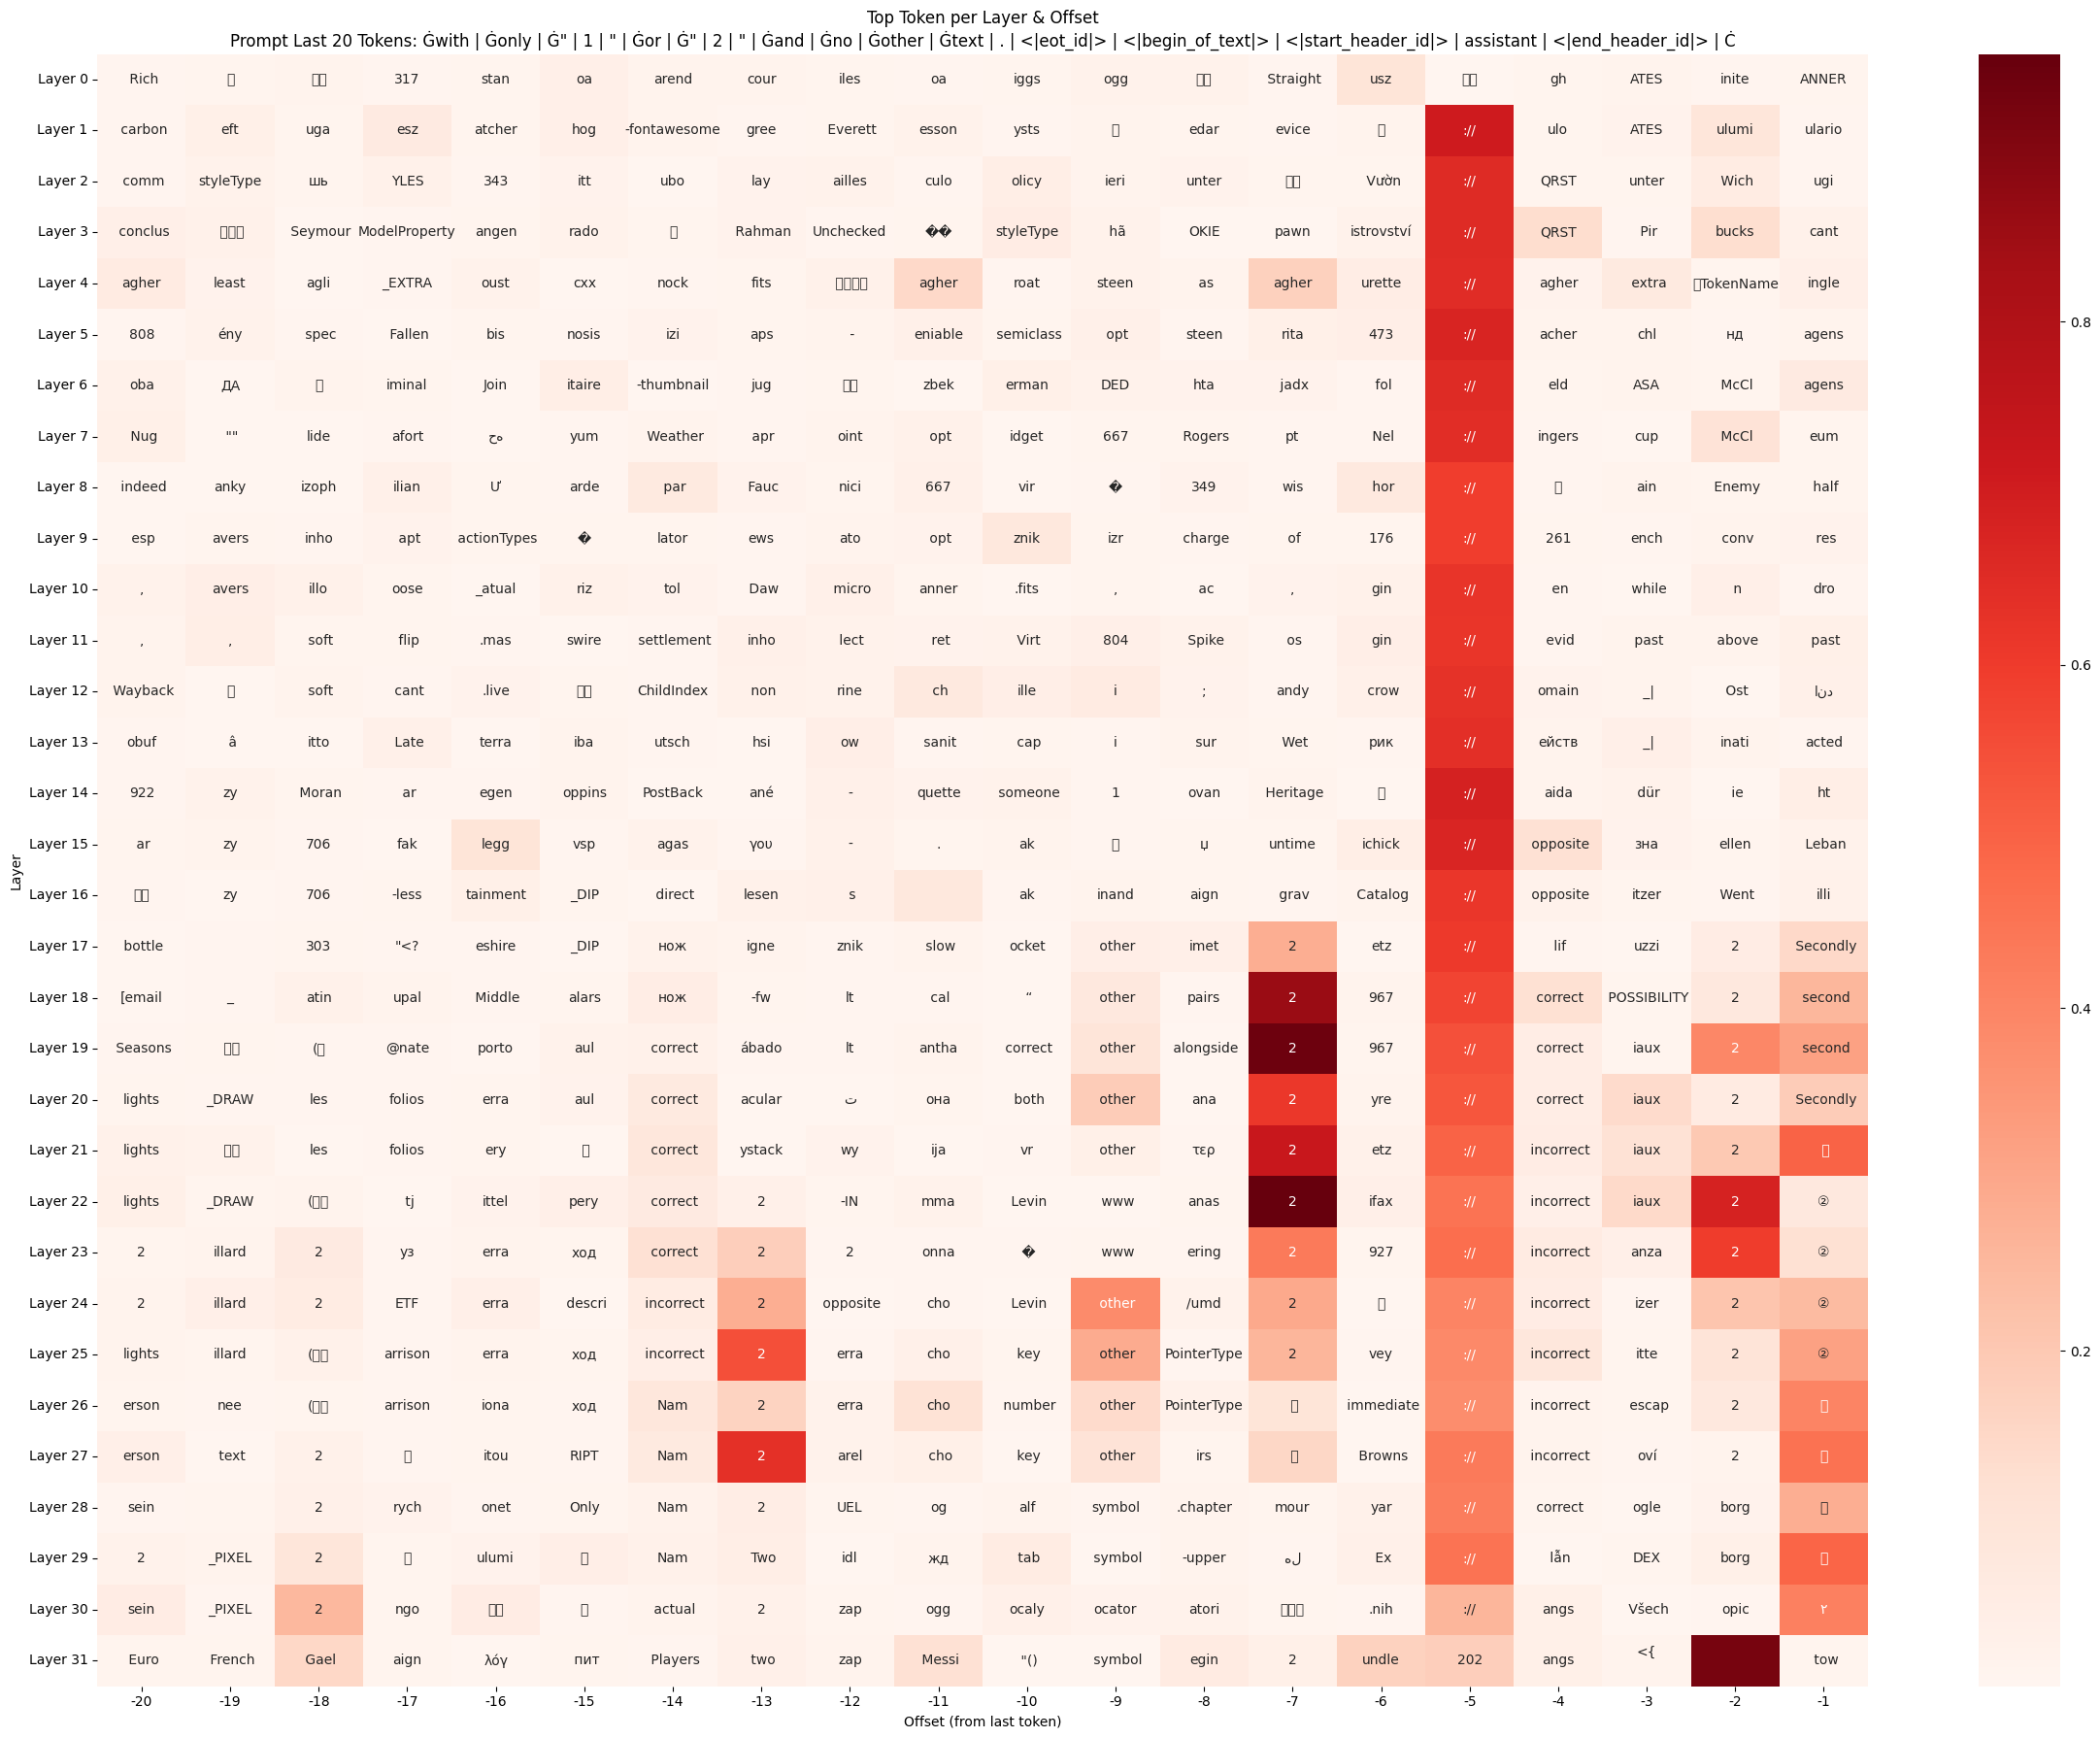

In [98]:
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

def show_top_token_heatmap_all_layers_offsets(layer_proj, model, tokenizer, prompt, K=10):
    """
    Shows a heatmap of the top token (decoded) for each layer and offset.
    Rows: layers (0-based)
    Columns: offsets (Kth-to-last to last token)
    """
    device = next(model.parameters()).device
    model_dtype = next(model.parameters()).dtype
    num_layers = max(layer_proj.keys()) + 1  # layers are 0-indexed

    enc = tokenizer(prompt, add_special_tokens=True, return_tensors="pt")
    ids = enc["input_ids"][0]
    last_k_ids = ids[-K:].tolist()
    last_k_tokens = tokenizer.convert_ids_to_tokens(last_k_ids, skip_special_tokens=False)

    # Prepare arrays for tokens and probabilities
    token_matrix = []
    prob_matrix = []

    for layer in range(num_layers):
        layer_tokens = []
        layer_probs = []
        for offset in range(1, K + 1):
            vec = layer_proj[layer][K-offset]
            vec = vec.to(device).to(model_dtype)
            normed = model.model.norm(vec)
            logits = model.lm_head(normed)
            probs = torch.softmax(logits, dim=-1)
            top_idx = torch.argmax(probs).item()
            top_token = tokenizer.decode([top_idx])
            top_prob = probs[top_idx].item()
            layer_tokens.append(top_token)
            layer_probs.append(top_prob)
        token_matrix.append(layer_tokens)
        prob_matrix.append(layer_probs)

    token_matrix = np.array(token_matrix)
    prob_matrix = np.array(prob_matrix)

    plt.figure(figsize=(K+4, num_layers/2+2))
    ax = sns.heatmap(prob_matrix, annot=token_matrix, fmt='', cmap="Reds",
                     xticklabels=[f"-{K-i}" for i in range(K)],
                     yticklabels=[f"Layer {i}" for i in range(num_layers)])
    plt.title(f"Top Token per Layer & Offset\nPrompt Last {K} Tokens: {' | '.join(last_k_tokens)}")
    plt.xlabel("Offset (from last token)")
    plt.ylabel("Layer")
    plt.tight_layout()
    plt.show()

# Example usage:
show_top_token_heatmap_all_layers_offsets(
    layer_proj={k: 1 * torch.stack(v) for k, v in projected_vectors_by_layer.items()},
    model=model,
    tokenizer=tok,
    prompt=prompt,
    K=20
)

In [ ]:
lenlayer_sums_yes[0]

20

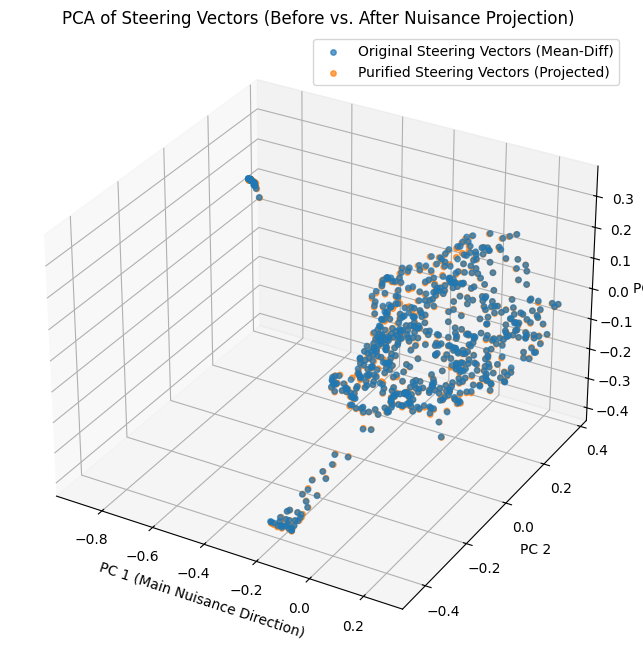

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Corrected Visualization ---
# We want to visualize the DIFFERENCE made by the projection.
# Therefore, we run PCA ONLY on the original and the projected steering vectors.

# 1. Stack the original steering vectors (Mean-Diff) and the purified ones (Projected)
original_vectors = np.vstack([torch.stack(vs).numpy() for vs in layer_diffs.values()])
projected_vectors = np.vstack([torch.stack(vs).numpy() for vs in projected_vectors_by_layer.values()])

# This is the dataset we will analyze
visualization_data = np.vstack([original_vectors, projected_vectors])

# 2. Run PCA on this combined dataset
pca_viz = PCA(n_components=3)
coords_viz = pca_viz.fit_transform(visualization_data)

# 3. Split the coordinates back into "original" and "projected" groups
n_original = original_vectors.shape[0]
coords_original = coords_viz[:n_original]
coords_projected = coords_viz[n_original:]

# 4. Plot the results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the original vectors (should have a wide spread along PC1)
ax.scatter(coords_original[:, 0], coords_original[:, 1], coords_original[:, 2], 
           s=15, label='Original Steering Vectors (Mean-Diff)', alpha=0.7)

# Plot the projected vectors (should be clustered tightly around 0 on the PC1 axis)
ax.scatter(coords_projected[:, 0], coords_projected[:, 1], coords_projected[:, 2], 
           s=15, label='Purified Steering Vectors (Projected)', alpha=0.7)

ax.set_title("PCA of Steering Vectors (Before vs. After Nuisance Projection)")
ax.set_xlabel("PC 1 (Main Nuisance Direction)")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.legend()
plt.show()

In [72]:
# --- Quantitative Analysis of the Visualization ---

# Calculate variance along each PC axis for both groups
variance_original_pc1 = np.var(coords_original[:, 0])
variance_projected_pc1 = np.var(coords_projected[:, 0])

variance_original_pc2 = np.var(coords_original[:, 1])
variance_projected_pc2 = np.var(coords_projected[:, 1])

# --- Print the results ---
print("--- Variance Analysis along PC 1 (Main Nuisance Direction) ---")
print(f"Variance of ORIGINAL vectors along PC 1: {variance_original_pc1:.6f}")
print(f"Variance of PURIFIED vectors along PC 1: {variance_projected_pc1:.6f}")

if variance_original_pc1 > 0:
    reduction = 100 * (1 - (variance_projected_pc1 / variance_original_pc1))
    print(f"--> Reduction in variance along the nuisance direction: {reduction:.2f}%")

print("\n--- Variance Analysis along PC 2 (A 'True' Steering Direction) ---")
print(f"Variance of ORIGINAL vectors along PC 2: {variance_original_pc2:.6f}")
print(f"Variance of PURIFIED vectors along PC 2: {variance_projected_pc2:.6f}")

--- Variance Analysis along PC 1 (Main Nuisance Direction) ---
Variance of ORIGINAL vectors along PC 1: 0.039944
Variance of PURIFIED vectors along PC 1: 0.038485
--> Reduction in variance along the nuisance direction: 3.65%

--- Variance Analysis along PC 2 (A 'True' Steering Direction) ---
Variance of ORIGINAL vectors along PC 2: 0.029657
Variance of PURIFIED vectors along PC 2: 0.029232
